# Evaluation: Basic RAG vs advanced agentic RAG (OpenAI)

- **Questions:** last 20 bullet items in `test_questions.md` (lines starting with `*`; file is append-only, newest at bottom). In the bundled file these are the 10 prompts under **Messy / vague user-style questions** plus 10 under **Scenario-style questions** (indirect wording).
- **Basic RAG:** `RagRetriever` + `answer_with_rag` (`src.rag`), generator `gpt-4o-mini`.
- **Advanced RAG:** `AdvancedRegulationAssistant` with OpenAI synthesizer (`src.advanced_rag`), see the diagram below for the system design. 
- **Judge:** `gpt-4o-mini` compares the two answers per question (JSON: preference, scores, rationale).

Requires `.env` with `OPENAI_API_KEY`, Pinecone settings, and ingested `chunks/` for retrieval.



### Advanced Rag diagram

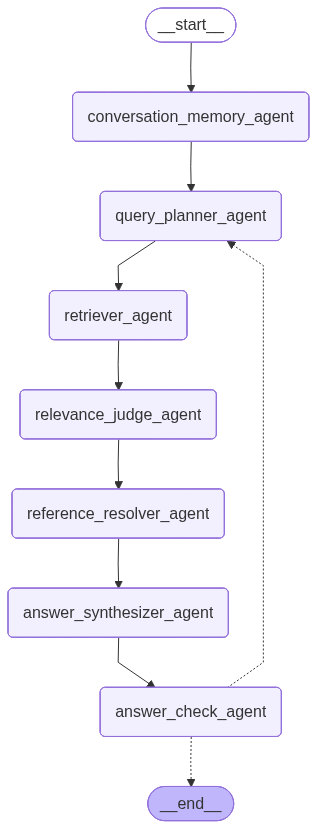

[ok] wrote advanced_rag_actual_langgraph.png


In [2]:
# LangGraph visualization: advanced_rag graph (PNG)
# This version plots the *intended retry* logic:
# - If answer check fails on first pass, retry goes back through the Query Planner.
# - On that retry, retrieval uses a larger k (state bumps top_k from 8 -> 12).

from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph

from src.advanced_rag.nodes import (
    answer_check_node,
    answer_synthesizer_node,
    conversation_memory_node,
    query_planner_node,
    reference_resolver_node,
    relevance_judge_node,
    retriever_node,
)
from src.advanced_rag.state import AdvancedRagState

try:
    from langchain_core.runnables.graph import MermaidDrawMethod
except Exception:  # pragma: no cover
    MermaidDrawMethod = None  # type: ignore


# NOTE: These are placeholders so we can *draw* the graph without running it.
# The lambdas capture them but nothing is executed during rendering.
client = object()
retriever = object()
model = "gpt-4o-mini"
TOP_K = 8
RETRY_TOP_K = 12


graph = StateGraph(AdvancedRagState)

graph.add_node(
    "conversation_memory_agent",
    lambda s: conversation_memory_node(s, client=client, model=model),
)

graph.add_node(
    "query_planner_agent",
    lambda s: query_planner_node(s, client=client, model=model),
)

graph.add_node(
    "retriever_agent",
    # `retriever_node` will actually use `state["top_k"]` if present; otherwise it falls back to TOP_K.
    lambda s: retriever_node(s, retriever=retriever, top_k=TOP_K),
)

graph.add_node(
    "relevance_judge_agent",
    lambda s: relevance_judge_node(s, client=client, model=model),
)

graph.add_node(
    "reference_resolver_agent",
    lambda s: reference_resolver_node(s, client=client, model=model, retriever=retriever),
)

synth_model = model

graph.add_node(
    "answer_synthesizer_agent",
    lambda s: answer_synthesizer_node(
        s,
        client=client,
        openai_model=synth_model,
    ),
)

graph.add_node(
    "answer_check_agent",
    # `answer_check_node` will (on first failure) increment retry_count,
    # append an additional_query_hint to the rewritten query, and bump state["top_k"] to >= RETRY_TOP_K.
    lambda s: answer_check_node(s, client=client, model=model),
)

# Edges

graph.add_edge(START, "conversation_memory_agent")

graph.add_edge("conversation_memory_agent", "query_planner_agent")

graph.add_edge("query_planner_agent", "retriever_agent")

graph.add_edge("retriever_agent", "relevance_judge_agent")

graph.add_edge("relevance_judge_agent", "reference_resolver_agent")

graph.add_edge("reference_resolver_agent", "answer_synthesizer_agent")

graph.add_edge("answer_synthesizer_agent", "answer_check_agent")


def _route_after_check(state: AdvancedRagState) -> str:
    if state.get("answer_supported", False):
        return END
    if state.get("retry_count", 0) >= 1:
        return END
    return "query_planner_agent"


graph.add_conditional_edges(
    "answer_check_agent",
    _route_after_check,
    {
        END: END,
        "query_planner_agent": "query_planner_agent",
    },
)

app = graph.compile()

# Render PNG in notebook (and save to disk)
kwargs = {}
if MermaidDrawMethod is not None:
    kwargs["draw_method"] = MermaidDrawMethod.API

png_bytes = app.get_graph().draw_mermaid_png(**kwargs)

out_path = "advanced_rag_actual_langgraph.png"
with open(out_path, "wb") as f:
    f.write(png_bytes)

display(Image(png_bytes))
print(f"[ok] wrote {out_path}")


In [1]:
from __future__ import annotations

import json
import os
import re
from pathlib import Path

from dotenv import load_dotenv
from openai import OpenAI

from src.advanced_rag import AdvancedRegulationAssistant
from src.rag.answer import answer_with_rag, build_context
from src.rag.retriever import RagRetriever

load_dotenv()

REPO = Path.cwd()
TEST_QUESTIONS_PATH = REPO / "test_questions.md"
N_QUESTIONS = 20
TOP_K = 5
GEN_MODEL = "gpt-4o-mini"
JUDGE_MODEL = "gpt-4o-mini"
MAX_CONTEXT_CHARS = 20000


def load_bullet_questions(md_path: Path, limit: int) -> list[str]:
    """Last `limit` markdown bullet lines that look like '* ...'."""
    text = md_path.read_text(encoding="utf-8")
    out: list[str] = []
    for line in text.splitlines():
        m = re.match(r"^\*\s+(.+?)\s*$", line.strip())
        if m:
            out.append(m.group(1).strip())

    # We use slicing because `test_questions.md` is append-only.
    # The most recently added questions are at the bottom.
    return out[-limit:] if len(out) >= limit else out


EVAL_QUESTIONS = load_bullet_questions(TEST_QUESTIONS_PATH, N_QUESTIONS)
assert len(EVAL_QUESTIONS) == N_QUESTIONS, (
    f"Expected {N_QUESTIONS} bullet questions in {TEST_QUESTIONS_PATH}, got {len(EVAL_QUESTIONS)}"
)
for i, q in enumerate(EVAL_QUESTIONS, start=1):
    print(f"{i:2}. {q}")

/Users/yihaochen/Desktop/MLDS GenAI/multi_agent_rags_f1_regulations/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 1. I'm trying to figure out whether I'm even in the right ruleset. Who is this framework meant for?
 2. When does this all become effective, like what "start date" should I use for planning?
 3. If someone challenges my interpretation, who is the authority that actually applies the rules?
 4. Can you explain the big picture goal of these rules without quoting the text?
 5. For a team in their first season, what kind of spending limit do they use, and how is it calculated?
 6. If my spending is split across different parts of the business, how do I decide what to ignore versus what to include?
 7. What are the typical categories of costs that usually get left out of the calculation?
 8. If an employee gets bonuses as part of a salary plan, is there a cap on what we can treat as excluded?
 9. Are staff travel and competition-related trips treated the same way as other business travel?
10. What happens if a category of cost looks similar to something excluded - how strict is the treatmen

In [2]:
if not os.environ.get("OPENAI_API_KEY"):
    raise RuntimeError("Set OPENAI_API_KEY (e.g. in .env)")

# Ensure the embedding model matches your Pinecone index dimension.
# `regs-2026-bgebased` typically corresponds to BGE-base (768-dim).
os.environ["EMBEDDING_MODEL"] = os.getenv("EMBEDDING_MODEL", "BAAI/bge-base-en")

INDEX_NAME = os.getenv("PINECONE_INDEX_NAME", "regs-2026-bgebased")
NAMESPACE = os.getenv("PINECONE_NAMESPACE", "regulations-2026")
PINECONE_HOST = os.getenv("PINECONE_HOST")

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

retriever = RagRetriever(
    model_name=os.environ["EMBEDDING_MODEL"],
    index_name=INDEX_NAME,
    host=PINECONE_HOST,
    namespace=NAMESPACE,
    chunks_root="chunks",
)

assistant = AdvancedRegulationAssistant(
    llm_model=GEN_MODEL,
    answer_synthesizer_openai_model=GEN_MODEL,
    top_k=TOP_K,
    chunks_root="chunks",
    index_name=INDEX_NAME,
    host=PINECONE_HOST,
    namespace=NAMESPACE,
)

print(f"index={INDEX_NAME} namespace={NAMESPACE} gen={GEN_MODEL} judge={JUDGE_MODEL} embed={os.environ['EMBEDDING_MODEL']}")

index=regs-2026-bgebased namespace=regulations-2026 gen=gpt-4o-mini judge=gpt-4o-mini embed=BAAI/bge-base-en


In [3]:
from typing import Any, Iterable


def _chunk_label(metadata: dict[str, Any]) -> str:
    """Short human label to help the LLM judge relevance."""
    keys = [
        "article_id",
        "appendix_id",
        "parent_clause_id",
        "clause_id",
        "clause_ids",
        "section",
        "document_title",
        "source_pdf",
        "page",
    ]
    parts: list[str] = []
    for k in keys:
        v = metadata.get(k)
        if v is None or v == "":
            continue
        if isinstance(v, list):
            v = ",".join(str(x) for x in v[:5])
        parts.append(f"{k}={v}")
    return " | ".join(parts)[:180]


def _as_eval_chunk(x: Any) -> dict:
    """Normalize both basic and advanced chunks into a single dict schema."""
    # Basic RAG: src.rag.retriever.RetrievalResult
    if hasattr(x, "id") and hasattr(x, "metadata"):
        return {
            "id": str(getattr(x, "id")),
            "score": float(getattr(x, "score", 0.0) or 0.0),
            "text": (getattr(x, "text", None) or ""),
            "metadata": dict(getattr(x, "metadata", {}) or {}),
            "source": "basic",
        }

    # Advanced RAG: src.advanced_rag.state.ChunkDoc (TypedDict)
    if isinstance(x, dict) and "id" in x and "text" in x:
        return {
            "id": str(x.get("id", "")),
            "score": float(x.get("score", 0.0) or 0.0),
            "text": str(x.get("text", "") or ""),
            "metadata": dict(x.get("metadata", {}) or {}),
            "source": str(x.get("source", "advanced")),
        }

    raise TypeError(f"Unsupported chunk type: {type(x)}")


def run_basic_rag(question: str) -> dict:
    hits = retriever.retrieve(question, top_k=TOP_K)
    ctx = build_context(hits, max_context_chars=MAX_CONTEXT_CHARS)
    if not ctx.strip():
        ans = "(no retrieval context)"
    else:
        ans = answer_with_rag(
            query=question,
            context=ctx,
            model=GEN_MODEL,
            client=client,
        )
    return {
        "answer": (ans or "").strip(),
        "chunks": [_as_eval_chunk(h) for h in hits],
    }


def run_advanced_rag(question: str, idx: int) -> dict:
    """Run advanced RAG and return both Stage 1 and Stage 2 retrieval.

    Stage 1: raw retriever output (`retrieved_chunks`)
    Stage 2: final context used for synthesis (`final_context_chunks`)
    """

    # Fresh session per question so memory does not carry across the eval set
    session_id = f"eval-advanced-{idx}"

    # Build the initial state using the assistant's normal defaults
    init_state = assistant._initial_state(query=question, session_id=session_id, chat_history=None)

    # Invoke the graph directly to capture intermediate state keys.
    out = assistant.graph.invoke(init_state)

    stage1 = [_as_eval_chunk(c) for c in (out.get("retrieved_chunks") or [])]
    stage2 = [_as_eval_chunk(c) for c in (out.get("final_context_chunks") or [])]

    return {
        "answer": str(out.get("draft_answer") or "").strip(),
        "chunks_stage1": stage1,
        "chunks_stage2": stage2,
    }


JUDGE_SYSTEM = """You are an expert evaluator for F1 Power Unit Financial Regulations Q&A.
You compare two answers to the same user question.
- Answer A was produced by **basic RAG**: retrieve chunks, then one LLM call over that context.
- Answer B was produced by **advanced agentic RAG**: multi-agent pipeline (planning, retrieval, judging, synthesis) with OpenAI.

Evaluate grounding (use of regulation concepts, avoiding obvious hallucination), correctness, and whether the answer addresses what was asked.
Return **only** a JSON object with exactly these keys:
- "preferred": one of "A", "B", "tie" (which answer is better overall; "tie" if similar quality)
- "base_rag_score": integer 1-5 (quality of Answer A)
- "advanced_rag_score": integer 1-5 (quality of Answer B)
- "rationale": string, at most 4 short sentences explaining the comparison"""


def judge_pair(question: str, answer_a: str, answer_b: str) -> dict:
    payload = (
        f"Question:\n{question}\n\n"
        f"Answer A (basic RAG):\n{answer_a}\n\n"
        f"Answer B (advanced agentic RAG):\n{answer_b}"
    )
    resp = client.chat.completions.create(
        model=JUDGE_MODEL,
        temperature=0,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": JUDGE_SYSTEM},
            {"role": "user", "content": payload},
        ],
    )
    raw = (resp.choices[0].message.content or "").strip()
    return json.loads(raw)


RETRIEVAL_JUDGE_MODEL = "gpt-4o-mini"

RETRIEVAL_JUDGE_SYSTEM = """You judge retrieval quality for a RAG system.
Given a question and a set of candidate chunks, mark which chunks are relevant for answering the question.
A chunk is relevant if it contains definitions, rules, thresholds, scope, responsibilities, dates, or procedures that directly help answer the question.

Return ONLY a JSON object with keys:
- "relevant_chunk_ids": array of chunk ids judged relevant
- "notes": short string (<=2 sentences)"""


def judge_relevant_chunk_ids(question: str, chunks: list[dict], *, max_chars_per_chunk: int = 900) -> set[str]:
    items = []
    for c in chunks:
        text = (c.get("text") or "").strip().replace("\u0000", "")
        if len(text) > max_chars_per_chunk:
            text = text[:max_chars_per_chunk] + "…"
        items.append(
            {
                "id": c.get("id"),
                "label": _chunk_label(c.get("metadata", {}) or {}),
                "text": text,
            }
        )

    payload = json.dumps({"question": question, "chunks": items}, ensure_ascii=False)
    resp = client.chat.completions.create(
        model=RETRIEVAL_JUDGE_MODEL,
        temperature=0,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": RETRIEVAL_JUDGE_SYSTEM},
            {"role": "user", "content": payload},
        ],
    )
    raw = (resp.choices[0].message.content or "").strip()
    obj = json.loads(raw)
    ids = obj.get("relevant_chunk_ids", [])
    if not isinstance(ids, list):
        return set()
    return {str(x) for x in ids if str(x).strip()}


def _unique_by_id(chunks: Iterable[dict]) -> list[dict]:
    out: list[dict] = []
    seen: set[str] = set()
    for c in chunks:
        cid = str(c.get("id", "")).strip()
        if not cid or cid in seen:
            continue
        seen.add(cid)
        out.append(c)
    return out


def ir_metrics_at_k(retrieved_ids: list[str], relevant_ids: set[str], *, k: int) -> dict:
    ids = [x for x in retrieved_ids if x]
    top = ids[:k]
    rel_ranks = [i for i, cid in enumerate(top, start=1) if cid in relevant_ids]

    precision = (len(rel_ranks) / k) if k > 0 else 0.0
    recall = (len(rel_ranks) / len(relevant_ids)) if relevant_ids else None
    mrr = (1.0 / rel_ranks[0]) if rel_ranks else 0.0

    return {
        f"precision@{k}": precision,
        f"recall@{k}": recall,
        "mrr": mrr,
        "relevant_found": len(rel_ranks),
        "relevant_total": len(relevant_ids),
    }


# -----------------
# Agentic fact-check
# -----------------

FACTCHECK_MODEL = "gpt-4o-mini"

FACTCHECK_CLAIMS_SYSTEM = """You extract atomic factual claims from an answer about FIA F1 Power Unit Financial Regulations.

Rules:
- Return claims that are factual and checkable against regulation text.
- Prefer splitting into small atomic claims (1 sentence each).
- Mark severity:
  - critical: numbers, thresholds, dates, must/shall obligations, scope, exclusions, definitions.
  - minor: wording nuances, non-essential context.

Return ONLY JSON with:
- claims: array of objects {text: string, severity: \"critical\"|\"minor\"}
"""

FACTCHECK_VERIFY_SYSTEM = """You are a strict fact-checker for FIA F1 regulation Q&A.

You MUST ONLY use the provided chunks as evidence. Do not use outside knowledge.

Task:
- For each claim, decide its status versus the evidence:
  - supported: directly supported by explicit text
  - partially_supported: some parts supported but missing specifics
  - insufficient_context: chunks do not contain the needed information
  - unsupported: chunks contain information but do not support the claim
  - contradicts: chunks explicitly contradict the claim

Evidence requirements:
- For supported/partially_supported/contradicts, include:
  - evidence_chunk_ids: list of chunk ids
  - quotes: 1-3 short direct quotes (<=200 chars each) copied from the chunk text
- If insufficient_context, evidence_chunk_ids may be empty.

Return ONLY JSON with keys:
- overall_verdict: one of supported|partially_supported|insufficient_context|unsupported|contradicts
- claims: array of {text, severity, status, evidence_chunk_ids, quotes}
- notes: <=2 sentences
"""


def _factcheck_items_from_chunks(chunks: list[dict], *, max_chars_per_chunk: int = 1200) -> list[dict]:
    items: list[dict] = []
    for c in chunks:
        text = (c.get("text") or "").strip().replace("\u0000", "")
        if len(text) > max_chars_per_chunk:
            text = text[:max_chars_per_chunk] + "…"
        items.append(
            {
                "id": str(c.get("id", "")),
                "label": _chunk_label(c.get("metadata", {}) or {}),
                "text": text,
            }
        )
    return items


def _fact_multiplier_from_claims(claims: list[dict]) -> float:
    mult = 1.0
    for c in claims or []:
        status = str(c.get("status") or "").strip()
        severity = str(c.get("severity") or "minor").strip()

        if status == "contradicts":
            return 0.0

        if status == "unsupported":
            mult -= 0.5 if severity == "critical" else 0.2
        elif status == "insufficient_context":
            mult -= 0.3 if severity == "critical" else 0.1
        elif status == "partially_supported":
            mult -= 0.2 if severity == "critical" else 0.05

    if mult < 0.0:
        mult = 0.0
    if mult > 1.0:
        mult = 1.0
    return float(mult)


def fact_check_answer(*, question: str, answer: str, chunks: list[dict]) -> dict:
    """Agentic fact-check: extract claims, then verify them against provided chunks only."""

    # Step 1: claim extraction
    resp1 = client.chat.completions.create(
        model=FACTCHECK_MODEL,
        temperature=0,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": FACTCHECK_CLAIMS_SYSTEM},
            {"role": "user", "content": json.dumps({"question": question, "answer": answer}, ensure_ascii=False)},
        ],
    )
    raw1 = (resp1.choices[0].message.content or "{}").strip()
    obj1 = json.loads(raw1)
    claims = obj1.get("claims", [])
    if not isinstance(claims, list):
        claims = []

    # Normalize claims
    norm_claims: list[dict] = []
    for c in claims:
        if not isinstance(c, dict):
            continue
        text = str(c.get("text") or "").strip()
        if not text:
            continue
        sev = str(c.get("severity") or "minor").strip()
        if sev not in ("critical", "minor"):
            sev = "minor"
        norm_claims.append({"text": text, "severity": sev})

    # Step 2: verify against chunks
    payload2 = {
        "question": question,
        "answer": answer,
        "claims": norm_claims,
        "chunks": _factcheck_items_from_chunks(chunks),
    }
    resp2 = client.chat.completions.create(
        model=FACTCHECK_MODEL,
        temperature=0,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": FACTCHECK_VERIFY_SYSTEM},
            {"role": "user", "content": json.dumps(payload2, ensure_ascii=False)},
        ],
    )
    raw2 = (resp2.choices[0].message.content or "{}").strip()
    obj2 = json.loads(raw2)

    out_claims = obj2.get("claims", [])
    if not isinstance(out_claims, list):
        out_claims = []

    # Ensure severity carried through
    sev_by_text = {c["text"]: c["severity"] for c in norm_claims}
    for c in out_claims:
        if isinstance(c, dict) and "text" in c:
            c.setdefault("severity", sev_by_text.get(str(c.get("text") or ""), "minor"))

    mult = _fact_multiplier_from_claims([c for c in out_claims if isinstance(c, dict)])

    return {
        "overall_verdict": obj2.get("overall_verdict"),
        "claims": out_claims,
        "notes": obj2.get("notes"),
        "fact_multiplier": mult,
    }


## Evaluation Metrics (Basic vs Advanced)

### Answer quality metrics

This notebook compares **Basic RAG** vs **Advanced RAG** using:

- **Answer quality (judge score)**: `judge_base_score` / `judge_advanced_score` from an LLM-based pairwise judge (1–5).
- **Agentic fact-check** (context-locked): `fact_check_answer()` extracts atomic claims from the answer, then verifies each claim strictly against the **chunks used by that system**.
  - Produces `fact_multiplier` in **[0, 1]** (unsupported/contradicting claims reduce it; correct abstention is less penalized).
- **Final score**: `final_score = judge_score × fact_multiplier`.

### Retrieval metrics (at `k = TOP_K`, default 5)
Retrieval metrics are computed by `ir_metrics_at_k()` using LLM-labeled `relevant_chunk_ids`.
- **Precision@5**: `#relevant_chunks_in_top5 / 5`
- **Recall@5**: `#relevant_chunks_in_top5 / #relevant_chunks_total`
- **MRR**: `1 / rank_of_first_relevant_chunk_in_top5` (0 if none in top-5)

**Advanced retrieval uses Stage 2 only**: the metrics are computed over `final_context_chunks` (the final context fed to the advanced synthesizer), not Stage 1 (`retrieved_chunks`).


In [5]:
rows: list[dict] = []

k = TOP_K

for i, q in enumerate(EVAL_QUESTIONS, start=1):
    print(f"\n--- Q{i}/{len(EVAL_QUESTIONS)} ---")
    print(q[:100] + ("…" if len(q) > 100 else ""))

    base = run_basic_rag(q)
    adv = run_advanced_rag(q, i)

    verdict = judge_pair(q, base.get("answer", ""), adv.get("answer", ""))

    base_chunks = list(base.get("chunks") or [])
    adv_stage2_chunks = list(adv.get("chunks_stage2") or [])

    base_fc = fact_check_answer(question=q, answer=base.get("answer", ""), chunks=base_chunks)
    adv_fc = fact_check_answer(question=q, answer=adv.get("answer", ""), chunks=adv_stage2_chunks)

    base_score = float(verdict.get("base_rag_score") or 0.0)
    adv_score = float(verdict.get("advanced_rag_score") or 0.0)
    base_final = base_score * float(base_fc.get("fact_multiplier") or 0.0)
    adv_final = adv_score * float(adv_fc.get("fact_multiplier") or 0.0)

    # Pool both systems' chunks (use advanced Stage 2 for parity with the answer),
    # judge relevance once, then score each system vs the same relevance set.
    pool = _unique_by_id([*base_chunks, *adv_stage2_chunks])
    relevant_ids = judge_relevant_chunk_ids(q, pool)

    base_ids = [str(c.get("id", "")) for c in base_chunks]
    adv_ids = [str(c.get("id", "")) for c in adv_stage2_chunks]

    base_m = ir_metrics_at_k(base_ids, relevant_ids, k=k)
    adv_m = ir_metrics_at_k(adv_ids, relevant_ids, k=k)

    rows.append(
        {
            "i": i,
            "question": q,
            "basic_rag_answer": base.get("answer", ""),
            "advanced_rag_answer": adv.get("answer", ""),
            "judge_preferred": verdict.get("preferred"),
            "judge_base_score": verdict.get("base_rag_score"),
            "judge_advanced_score": verdict.get("advanced_rag_score"),
            "judge_rationale": verdict.get("rationale"),
            # Fact-check (answer vs its own chunks)
            "basic_fact_overall_verdict": base_fc.get("overall_verdict"),
            "basic_fact_multiplier": base_fc.get("fact_multiplier"),
            "advanced_fact_overall_verdict": adv_fc.get("overall_verdict"),
            "advanced_fact_multiplier": adv_fc.get("fact_multiplier"),
            "basic_final_score": base_final,
            "advanced_final_score": adv_final,
            # Retrieval quality (LLM-judged relevance + IR metrics)
            f"basic_precision@{k}": base_m.get(f"precision@{k}"),
            f"basic_recall@{k}": base_m.get(f"recall@{k}"),
            "basic_mrr": base_m.get("mrr"),
            f"advanced_precision@{k}": adv_m.get(f"precision@{k}"),
            f"advanced_recall@{k}": adv_m.get(f"recall@{k}"),
            "advanced_mrr": adv_m.get("mrr"),
            "pool_relevant_total": base_m.get("relevant_total"),
            "basic_relevant_found": base_m.get("relevant_found"),
            "advanced_relevant_found": adv_m.get("relevant_found"),
        }
    )

    print(
        "preferred:",
        verdict.get("preferred"),
        "| scores A/B:",
        verdict.get("base_rag_score"),
        "/",
        verdict.get("advanced_rag_score"),
        f"| P@{k} basic/adv:",
        round(float(base_m.get(f"precision@{k}") or 0.0), 3),
        "/",
        round(float(adv_m.get(f"precision@{k}") or 0.0), 3),
        "| MRR basic/adv:",
        round(float(base_m.get("mrr") or 0.0), 3),
        "/",
        round(float(adv_m.get("mrr") or 0.0), 3),
        "| fact_mult basic/adv:",
        round(float(base_fc.get("fact_multiplier") or 0.0), 3),
        "/",
        round(float(adv_fc.get("fact_multiplier") or 0.0), 3),
        "| final basic/adv:",
        round(float(base_final or 0.0), 3),
        "/",
        round(float(adv_final or 0.0), 3),
    )

rows


--- Q1/20 ---
I'm trying to figure out whether I'm even in the right ruleset. Who is this framework meant for?
preferred: B | scores A/B: 3 / 5 | P@5 basic/adv: 0.0 / 0.2 | MRR basic/adv: 0.0 / 1.0 | fact_mult basic/adv: 0.6 / 1.0 | final basic/adv: 1.8 / 5.0

--- Q2/20 ---
When does this all become effective, like what "start date" should I use for planning?
preferred: B | scores A/B: 2 / 5 | P@5 basic/adv: 0.0 / 0.6 | MRR basic/adv: 0.0 / 1.0 | fact_mult basic/adv: 1.0 / 1.0 | final basic/adv: 2.0 / 5.0

--- Q3/20 ---
If someone challenges my interpretation, who is the authority that actually applies the rules?
preferred: B | scores A/B: 3 / 5 | P@5 basic/adv: 0.0 / 0.4 | MRR basic/adv: 0.0 / 1.0 | fact_mult basic/adv: 0.8 / 1.0 | final basic/adv: 2.4 / 5.0

--- Q4/20 ---
Can you explain the big picture goal of these rules without quoting the text?
preferred: B | scores A/B: 4 / 5 | P@5 basic/adv: 0.0 / 0.0 | MRR basic/adv: 0.0 / 0.0 | fact_mult basic/adv: 0.0 / 1.0 | final basic/ad

[{'i': 1,
  'question': "I'm trying to figure out whether I'm even in the right ruleset. Who is this framework meant for?",
  'basic_rag_answer': 'The framework is meant for Formula 1 teams, as indicated by the context referring to financial regulations specific to F1 teams [Chunk 1].',
  'advanced_rag_answer': 'The FIA F1 Regulations are meant for F1 Teams, PU Manufacturers, and other Covered Persons involved in Formula 1. They must comply with the FIA Rules and Regulations at all times, as stated in Article A5.1.1.',
  'judge_preferred': 'B',
  'judge_base_score': 3,
  'judge_advanced_score': 5,
  'judge_rationale': "Answer B provides a more comprehensive response by specifying not only F1 teams but also PU manufacturers and other covered persons, which directly addresses the user's query about the intended audience of the framework. It also cites a specific article, enhancing its grounding in the regulations. Answer A is correct but lacks detail and context.",
  'basic_fact_overall_

In [7]:
# Summary (run after the eval cell)
import csv
from collections import Counter
from statistics import mean

prefs = [str(r["judge_preferred"] or "").strip().upper() for r in rows]
print("Judge preferences (gpt-4o-mini):")
for k, v in sorted(Counter(prefs).items(), key=lambda kv: -kv[1]):
    print(f"  {k}: {v}")

def _num(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return None


def _mean(xs):
    xs = [x for x in xs if x is not None]
    return round(mean(xs), 3) if xs else None


# Answer quality
bs = [v for r in rows if (v := _num(r.get("judge_base_score"))) is not None]
ad = [v for r in rows if (v := _num(r.get("judge_advanced_score"))) is not None]
print()
_mb = _mean(bs)
_ma = _mean(ad)
print(f"Mean answer scores — basic RAG: {_mb if _mb is not None else 'n/a'} | advanced: {_ma if _ma is not None else 'n/a'}")


# Retrieval quality
if rows:
    p_key = next((k for k in rows[0].keys() if k.startswith("basic_precision@")), None)
    r_key = next((k for k in rows[0].keys() if k.startswith("basic_recall@")), None)
    if p_key:
        bp = _mean([_num(r.get(p_key)) for r in rows])
        ap = _mean([_num(r.get(p_key.replace("basic_", "advanced_"))) for r in rows])
        print(f"Mean retrieval {p_key} — basic: {bp if bp is not None else 'n/a'} | advanced: {ap if ap is not None else 'n/a'}")
    if r_key:
        br = _mean([_num(r.get(r_key)) for r in rows])
        ar = _mean([_num(r.get(r_key.replace("basic_", "advanced_"))) for r in rows])
        print(f"Mean retrieval {r_key} — basic: {br if br is not None else 'n/a'} | advanced: {ar if ar is not None else 'n/a'}")

bmrr = _mean([_num(r.get("basic_mrr")) for r in rows])
amrr = _mean([_num(r.get("advanced_mrr")) for r in rows])
print(f"Mean retrieval MRR — basic: {bmrr if bmrr is not None else 'n/a'} | advanced: {amrr if amrr is not None else 'n/a'}")


# Write CSV
out_csv = REPO / "eval_basic_vs_advanced_openai.csv"
fieldnames = list(rows[0].keys()) if rows else []
if fieldnames:
    with out_csv.open("w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
        w.writeheader()
        w.writerows(rows)
    print(f"Wrote {out_csv}")


Judge preferences (gpt-4o-mini):
  B: 12
  A: 5
  TIE: 3

Mean answer scores — basic RAG: 3.6 | advanced: 4.15
Mean retrieval basic_precision@5 — basic: 0.22 | advanced: 0.19
Mean retrieval basic_recall@5 — basic: 0.553 | advanced: 0.5
Mean retrieval MRR — basic: 0.412 | advanced: 0.422
Wrote /Users/yihaochen/Desktop/MLDS GenAI/multi_agent_rags_f1_regulations/eval_basic_vs_advanced_openai.csv


In [ ]:
# see tok k results of what is a reporting group
# Show the top-k retrieval results of "What is a Reporting Group?" using the existing retriever/QA pipeline.
# This assumes you have a retriever or similar function available from earlier notebook cells, e.g. `retriever` or relevant RAG pipeline.

QUESTION = "What is a Reporting Group?"

# If you have a retriever object that exposes a .retrieve or .search or .__call__ method, adapt accordingly.
# Some common names might be: retriever, vectorstore, db, or pipeline.

# TOP_K can be changed to see more or fewer results
TOP_K = 5

try:
    # Try different names for your retriever/vectorstore object or pipeline as appropriate
    results = retriever.retrieve(QUESTION, top_k=TOP_K)
except Exception as e:
    # Try fallback to 'vectorstore' if retriever does not exist
    try:
        results = vectorstore.similarity_search(QUESTION, k=TOP_K)
    except Exception as e2:
        print("Unable to obtain retrieval results. Please check that your retriever/vectorstore pipeline is available.")
        results = []

if not results:
    print("No retrieval results found or retriever not defined.")
else:
    print(f"\nTop {TOP_K} chunks for: \"{QUESTION}\"")
    for i, chunk in enumerate(results):
        # Try the common fields for text chunk:
        chunk_text = chunk.get("text", "") if isinstance(chunk, dict) else str(chunk)
        print(f"\n--- Chunk #{i+1} ---")
        print(chunk_text[:1500])  # Print up to 1500 chars for readability
        # Optionally print metadata if available
        if isinstance(chunk, dict) and "metadata" in chunk:
            print("Metadata:", chunk["metadata"])


Top 5 chunks for: "What is a Reporting Group?"

--- Chunk #1 ---
RetrievalResult(id='ch_54e83bfbc8f0e074dc71', score=0.804290831, metadata={'article_id': 'D6', 'chunk_scope': 'subclause', 'chunk_text': 'If costs or losses incurred by a Reporting Group Entity are not recognised within its Total Costs, which under the applicable accounting standards should have been recognised within profit or loss during the Financial Regulations Reporting Period, an adjustment must be made in the calculation of Relevant Costs to ensure such costs are recognised within Relevant Costs for the Financial Regulations Reporting Period.', 'clause_ids': [], 'has_table': False, 'page_indices': ['13', '14', '15', '16', '17'], 'parent_clause_id': 'D6.1', 'scope': 'article', 'source_file': 'fia_2026_f1_regulations_-_section_d_financial_-_f1_teams_-_iss_05_-_2026-02-27.pdf_by_PaddleOCR-VL_no_strike.chunks.jsonl', 'source_row': 20}, text='If costs or losses incurred by a Reporting Group Entity are not recognised wi